In [1]:
import pandas as pd
import numpy as np
import scipy.io as sio
import torch
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import PCA_features

In [2]:
phase1_data = sio.loadmat('../data/mine_impact_data_2019.mat')
samples  = pd.DataFrame(phase1_data["x"].T)
labels  = pd.DataFrame(phase1_data["y"].T, columns=["y"])

df = pd.concat([samples, labels], axis=1, join="inner")

df = df.dropna()


In [3]:

shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

data_P1 = PCA_features(df_X, df_Y,explained_variance=0.95)


In [4]:
print(data_P1.get_samples().shape)

(3309, 396)


In [5]:
from sklearn.svm import SVC, LinearSVC

svc = SVC(kernel="rbf", C=100)
svc.fit(data_P1.get_samples()[:3000], data_P1.get_labels()[:3000])
print(svc.score(data_P1.get_samples()[3000:], data_P1.get_labels()[3000:]))


0.8576051779935275


              precision    recall  f1-score   support

           0       0.92      0.87      0.90       215
           1       0.74      0.82      0.78        94

    accuracy                           0.86       309
   macro avg       0.83      0.85      0.84       309
weighted avg       0.86      0.86      0.86       309



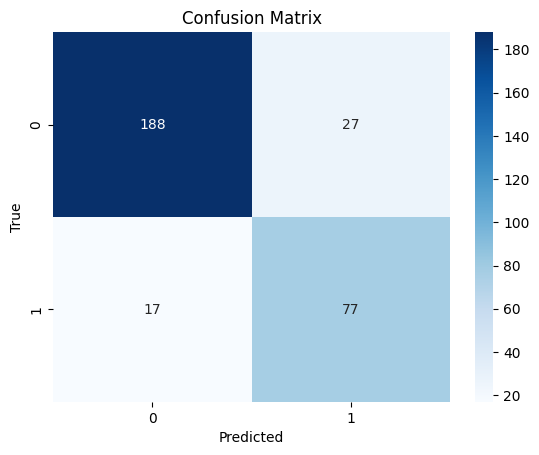

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = svc.predict(data_P1.get_samples()[3000:])

print(classification_report(data_P1.get_labels()[3000:], y_pred))


cm = confusion_matrix(data_P1.get_labels()[3000:], y_pred)
#matplot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(data_P1.get_labels()), yticklabels=np.unique(data_P1.get_labels()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
# Save the PCA features


#we aim to maximize recall for class 0
#Precision = 0.93 
# Of all items  model predicted as “0”, 93% were actually 0.
#Recall = 0.88
#Of the 215 true class-0 samples, 88% were correctly identified.


# Class 1
# Precision = 0.75
# When the model predicts “1”, it’s correct 75% of the time.
# Recall = 0.84
# Of the 94 true class-1 samples, 84% were caught.
# F1-score = 0.79
# Balances the lower precision (0.75) with the recall (0.84).


In [8]:
drummy_count = np.sum(data_P1.get_labels() == 0)
print(f"Drummy count: {drummy_count}")

Drummy count: 2212
